# PRACTICAL SESSION 05:
Simulating the dynamics of a massive perturber in a Plummer sphere

## IMPORT MODULES

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import constants as const
from astropy import units as u

from scipy.stats import norm
from scipy.stats import uniform

## CHOSE UNITS

In [2]:
# Chosen units (same name as in astropy https://docs.astropy.org/en/stable/units/#module-astropy.units.astrophys)
my_u = ["pc","year","M_sun"]

# Physical constants converted to chosen units
G = const.G.to(my_u[0] + "^3/(" + my_u[1] + "^2" + my_u[2]+")").value
c = const.c.to(my_u[0] + "/" + my_u[1]).value
print("G =", G, "\nc =", c)

# Conversion constants between physical and internal units
R0 = 1.
M0 = 2 # R0**3 / (G * T0**2)
T0 = np.sqrt(R0**3 / (G * M0)) # 1000

G = 4.498502151469552e-15 
c = 0.30660139378555057


# 1 - INPUT GENERATION:
Refer to PS04 for the generation of a stable Plummer sphere. Use as starting point one of the inputs or the outputs

In [4]:
# USEFUL FUNCTIONS

# Mass of the Plummer sphere as a function of radius
def mass(R):
    return R**3 / (1 + R**2)**(3/2)

# Radius as a function of mass (useful to generate r with the inverse function method)
def radius(M):
  return 1 / np.sqrt(1 / M**(2/3) - 1)
# NOTE: mass and radius are normalized respectively by total mass and scale radius

# Gravitational potential normalized by -U
def psi(r):
  return 1 / np.sqrt(1 + r**2)
# NOTE: the density is proportional to psi^5

def f(q):
    E = 1 - q**2
    mask = (E > 0) & (q > 0)
    out = np.zeros(q.shape)
    out[mask] = q[mask]**2 * E[mask]**(7/2)
    return out

## SET THE SYSTEM

### Plummer sphere

In [5]:
# SETTING SOME CONSTANTS

N = 5000

# System properties (defining normalization factors)
a = 10 # scale radius
M = 10000 # total mass
U = G * M / a # normalization of the potential

# Masses - considering N p.cles of equal mass
m = M / N * np.ones(N)

In [6]:
# Radii
rho = radius(uniform.rvs(size=N))

# Angular positions
phi = 2 * np.pi * uniform.rvs(size=N)
the = np.arccos(1 - 2 * uniform.rvs(size=N))

x = a * rho * np.sin(the) * np.cos(phi)
y = a * rho * np.sin(the) * np.sin(phi)
z = a * rho * np.cos(the)

In [7]:
# Velocity modulus sampling (could be implemented in a function)

n = N * 2
qs = np.linspace(0, 1, n)

gaus = norm(.47, .2) # chosen by eye
k = np.max(f(qs) / gaus.pdf(qs)) # 'normalization' constant of the gaussians

qs = gaus.rvs(size=n)
us = uniform.rvs(size=n)

mask = f(qs) / (k * gaus.pdf(qs)) > us
print('Accepted values: ', qs[mask].shape)

Accepted values:  (9176,)


In [8]:
# Velocity magnitudes
vel = np.sqrt(2 * U * psi(rho)) * qs[mask][:N]

# Velocity directions
csi = 2 * np.pi * uniform.rvs(size=N)
zet = np.arccos(1 - 2 * uniform.rvs(size=N))

vx = vel * np.sin(zet) * np.cos(csi)
vy = vel * np.sin(zet) * np.sin(csi)
vz = vel * np.cos(zet)

### Massive perturber

In [16]:
Lambda, R_ext = 100, radius(.9) # radii are normalized by a
R_per = 2 * R_ext / 3

M_per = M * mass(R_per) * R_ext / (R_per * Lambda)

# Set the position
x_per = a * R_per
y_per = 0
z_per = 0

# Set the circular velocity
vx_per = 0
vy_per = np.sqrt(G * M * mass(R_per) / (a * R_per))
vz_per = 0

## INTEGRATION PARAMETERS

In [9]:
# VELOCITY DISPERTION NEAR THE PERTURBER

n = 10000
vs, r = np.meshgrid(np.linspace(0, 5, n), R_per * np.ones(2))

k = np.max(f(r, vs) / norm.pdf(vs), axis=1)
__, k = np.meshgrid(np.linspace(0, 5, n), k)

vm = np.sqrt(2 * psi(r))
gaus = norm(vm / 2, vm / 4)

vs = gaus.rvs()
us = uniform.rvs(size=vs.shape)

mask = f(r, vs) / (k * gaus.pdf(vs)) <= us
vs[mask] = np.nan

sigma = vs[~np.isnan(vs)] * np.sqrt(U)
sigma = sigma.std()

R_i = G * M_per / sigma**2 # in chosen units (not normalized by a)
print('R_i =', round(R_i, 2))

R_i = 5.6


In [12]:
# INTEGRATION PARAMETERS (for treecode)
# NOTE: parameters must be converted in internal units

eps, alpha = 1.5, .05

r_orb = a * R_per
M_orb = M * mass(R_per)
T_orb = 2 * np.pi * r_orb**(3/2) / np.sqrt(G * M_orb)

T_frc = 1.17 * (a * R_per)**2 * vy_per / (np.log(Lambda) * G * M_per)

M_eps = M * eps**3 / (eps**2 + a**2)**(3/2)
T_eps = 2 * np.pi * eps**(3/2) / np.sqrt(G * M_eps)

t_eps = eps**(3/2) / np.sqrt(G * m[0])

print('M(R_per) =', round(M_orb / M0, 2), '\tT_orb =', round(T_orb / T0, 2))
print('T_frc =', round(T_frc / T0, 2))
print('M(eps) =', round(M_eps / M0, 2), '\tT_eps =', round(T_eps / T0, 2))
print('m_p =', round(m[0] / M0, 2), '\tt_eps =', round(t_eps / T0, 2))
print('Conversion constants: R0 =', R0, 'T0 =', T0, 'M0 =', M0)

NameError: name 'R_per' is not defined

## PRINT FILE

In [17]:
# ADD PERTURBER TO THE SYSTEM
N += 1

m = np.hstack((m, M_per))

x, y, z = np.hstack((x, x_per)), np.hstack((y, y_per)), np.hstack((z, z_per))

vx, vy, vz = np.hstack((vx, vx_per)), np.hstack((vy, vy_per)), np.hstack((vz, vz_per))

In [11]:
# FOR TREECODE

file_in = 'IF04.txt'

m = m / M0

x = x / R0
y = y / R0
z = z / R0

vx = vx / R0 * T0
vy = vy / R0 * T0
vz = vz / R0 * T0

n_dim = 3
time_in = 0 # initial time

out_r = np.column_stack((x, y, z))
out_v = np.column_stack((vx, vy, vz))
with open(file_in, 'w') as file:
    file.write(f'{N}\n')
    file.write(f'{n_dim}\n')
    file.write(f'{time_in}\n')
    for i in m:
        file.write(f'{i}\n')
    np.savetxt(file, out_r)
    np.savetxt(file, out_v)

# 2 - ANALYSIS
IF01 doesn't contain the right set up for perturber: first check the radius of the Plummer, then set the perturber

In [17]:
# Reading file

file_out = 'OF04-2.txt'

N = 5000
n = 3 * N + 3 # 'block' length
m = 3     # number of rows to skip (i.e. lines containing n. bodies and time)

time_rows = []
m_rows, r_rows, v_rows = [], [], []
with open(file_out, "r") as file:
    lines = file.readlines()
    for i in range(0, len(lines), n):  # move through rows every n rows
        time_rows.extend(lines[i+2:i+m])
        m_rows.extend(lines[i+m:i+N+3])
        r_rows.extend(lines[i+N+3:i+2*N+3])
        v_rows.extend(lines[i+2*N+3:i+n])

time = np.loadtxt(time_rows)

In [18]:
# FETCHING DATA

m = np.loadtxt(m_rows) # masses

r = np.loadtxt(r_rows) # positions
d = np.linalg.norm(r, axis=1) # distance from center

v = np.loadtxt(v_rows) # velocities
vm = np.linalg.norm(v, axis=1)


# MOVE TO CM FRAME

x, y, z = r[:, 0].reshape(time.size, N), r[:, 1].reshape(time.size, N), r[:, 2].reshape(time.size, N)

_, x_cm = np.meshgrid(np.zeros(N), x.mean(axis=1))
_, y_cm = np.meshgrid(np.zeros(N), y.mean(axis=1))
_, z_cm = np.meshgrid(np.zeros(N), z.mean(axis=1))

x_CM = x - x_cm
y_CM = y - y_cm
z_CM = z - z_cm

d_CM = np.sqrt(x_CM**2 + y_CM**2 + z_CM**2)

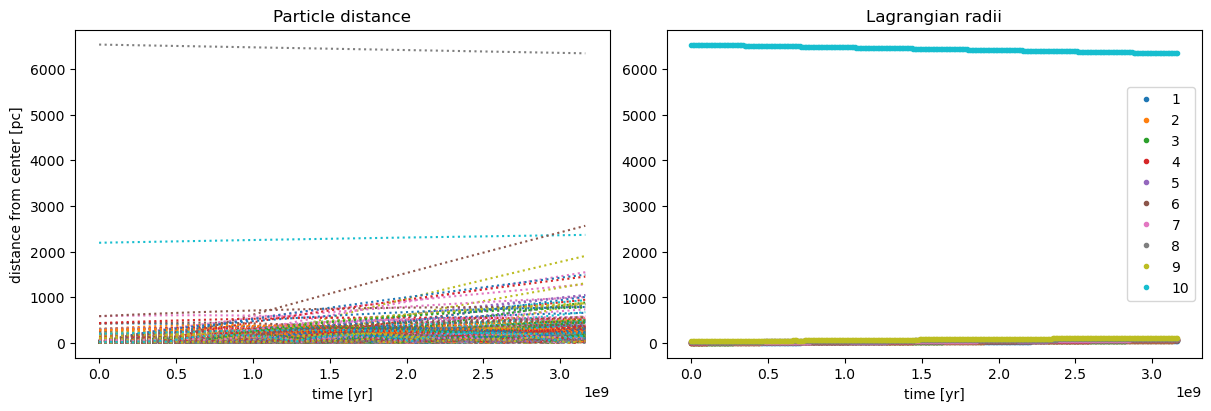

In [19]:
# Plotting distance vs time in the CF

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

d_mtx = d.reshape((time.size, N))
d_sort = np.sort(d_mtx, axis=1)

# Distance from the CF center of each p.cle
for i in range(N):
    #ax.plot(time, d[i::N], '.')
    ax.plot(time * T0, d_mtx[:, i], ':')

ax.set_title('Particle distance')
ax.set_xlabel('time [yr]')
ax.set_ylabel('distance from center [pc]')

# Lagrangian radii in the CF
for i in range(10):
    bx.plot(time * T0, d_sort[:, int((i+1) * N / 10) - 1], '.', label=i+1)

#bx.set_ylim(0, 100)

bx.set_title('Lagrangian radii')
bx.set_xlabel('time [yr]')
bx.legend()

plt.show()

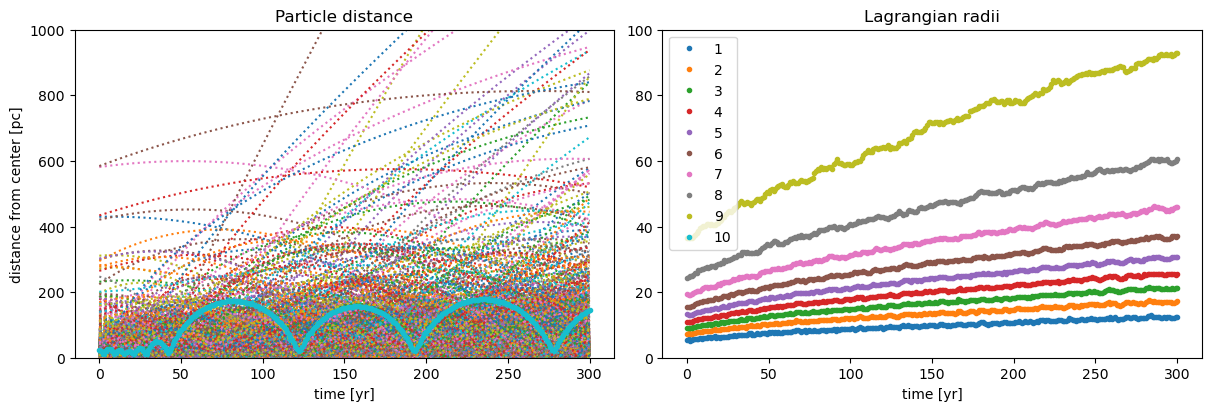

In [20]:
# Plotting distance vs time in the system center (i.e. the CM)

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

d_s = np.sort(d_CM, axis=1)

# Distance of each p.cle from the CM
for i in range(N-1):
    ax.plot(time, d_CM[:, i], ':')
ax.plot(time, d_CM[:, -1], '.')
ax.set_ylim(0, 1000)

ax.set_title('Particle distance')
ax.set_xlabel('time [yr]')
ax.set_ylabel('distance from center [pc]')

# Lagrangian radii
for i in range(10):
    bx.plot(time, d_s[:, int((i+1) * N / 10) - 1], '.', label=i+1)

bx.set_ylim(0, 100)

bx.set_title('Lagrangian radii')
bx.set_xlabel('time [yr]')
bx.legend()

plt.show()

# TEST

In [17]:
# Reading last configuration

file_out = '../PS04/IF05.txt'

m_rows, r_rows, v_rows = [], [], []
with open(file_out, 'r') as file:
    lines = file.readlines()
    N = int(lines[0]) # number of p.cles
    n_dim = int(lines[1]) # dimension
     
    n = len(lines) - 3 * N

    # Save the last configuration
    time_in = int(lines[n-1])
    m_rows.extend(lines[n:n+N])
    r_rows.extend(lines[n+N:n+2*N])
    v_rows.extend(lines[n+2*N:-1])

In [18]:
# FETCHING DATA

m = np.loadtxt(m_rows) # masses
r = np.loadtxt(r_rows) # positions
v = np.loadtxt(v_rows) # velocities


# COMPUTE CM POSITION (to be added to perturber coordinates)

r_cm = r.mean(axis=0) # coordinates of the CM in the original frame

In [19]:
test = np.vstack((r, [0, 0, 0]))
test[-1]

array([0., 0., 0.])

In [16]:
# USEFUL FUNCTIONS

# Gravitational potential normalized by -U
def psi(r):
    return 1 / np.sqrt(1 + r**2)
# NOTE: the density is proportional to psi^5

def f(q):
    E = 1 - q**2
    mask = (E > 0) & (q > 0)
    out = np.zeros(q.shape)
    out[mask] = q[mask]**2 * E[mask]**(7/2)
    return out

In [54]:
# Velocity modulus sampling

n = N * 100
qs = np.linspace(0, 1, n)

gaus = norm(.47, .2) # chosen by eye
k = np.max(f(qs) / gaus.pdf(qs)) # 'normalization' constant of the gaussians

qs = gaus.rvs(size=n)
us = uniform.rvs(size=n)

mask = f(qs) / (k * gaus.pdf(qs)) > us

r = radius(uniform.rvs(size=N))

U = 1
vel = np.sqrt(2 * U * psi(r)) * qs[mask][:N]

In [60]:
qs[mask].min()

0.009246041839724772

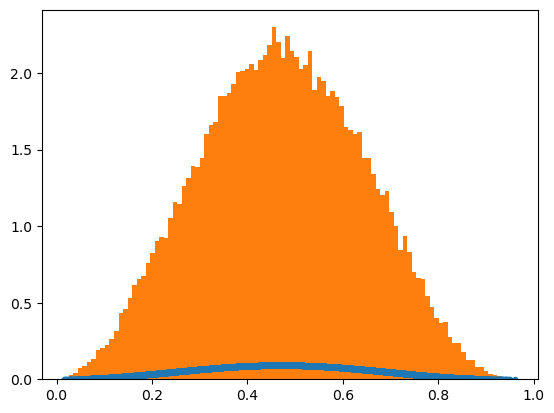

In [45]:
plt.plot(qs, f(qs), '.')
plt.hist(qs[~mask], bins=100, density=True);